In [1]:
import requests
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd

# Wikidata SPARQL endpoint
WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"

# Function to check if a concept exists in Wikidata
def check_wikidata_concept(concept_label):
    query = f"""
    SELECT ?item ?itemLabel WHERE {{
      ?item rdfs:label "{concept_label}"@en.
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }}
    """
    sparql = SPARQLWrapper(WIKIDATA_SPARQL_URL)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()

    return results["results"]["bindings"]

# Function to suggest ontology placement based on similarity
def suggest_superclass(concept_label):
    query = f"""
    SELECT ?item ?itemLabel WHERE {{
      ?item wdt:P31 wd:Q11173;  # Instance of "Chemical Compound"
            rdfs:label ?itemLabel.
      FILTER(CONTAINS(LCASE(?itemLabel), "{concept_label.lower()}"))
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }}
    LIMIT 5
    """
    sparql = SPARQLWrapper(WIKIDATA_SPARQL_URL)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()

    return results["results"]["bindings"]

# Function to process a list of candidate concepts
def process_concepts(concept_list):
    data = []
    for concept in concept_list:
        exists = check_wikidata_concept(concept)
        if exists:
            status = "Exists in Wikidata"
            superclass_suggestions = []
        else:
            status = "Not found"
            superclass_suggestions = suggest_superclass(concept)

        data.append({
            "Concept": concept,
            "Status": status,
            "Suggested Superclasses": [s["itemLabel"]["value"] for s in superclass_suggestions]
        })

    return pd.DataFrame(data)

# Example test cases (these would be extracted from an LLM response in real use)
concepts_to_check = ["Methoxychlor", "HypotheticalElementX", "BioactiveMoleculeZ"]

# Process the concepts and display the results
results_df = process_concepts(concepts_to_check)

# Print or save results
print(results_df)


                Concept              Status Suggested Superclasses
0          Methoxychlor  Exists in Wikidata                     []
1  HypotheticalElementX           Not found                     []
2    BioactiveMoleculeZ           Not found                     []


In [4]:
import requests
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd

WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"

# Function to check if a concept exists in Wikidata
def check_wikidata_concept(concept_label):
    query = f"""
    SELECT ?item ?itemLabel WHERE {{
      ?item rdfs:label "{concept_label}"@en.
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }}
    """
    sparql = SPARQLWrapper(WIKIDATA_SPARQL_URL)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()

    return results["results"]["bindings"]

# Improved: Function to get superclass using multiple properties
def suggest_superclass(concept_label):
    query = f"""
    SELECT ?superclass ?superclassLabel WHERE {{
      ?compound rdfs:label "{concept_label}"@en.
      ?compound (wdt:P279 | wdt:P31 | wdt:P361) ?superclass.  # Subclass, Instance, or Broader Category
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }}
    LIMIT 5
    """
    sparql = SPARQLWrapper(WIKIDATA_SPARQL_URL)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()

    return results["results"]["bindings"]

# Function to process a list of candidate concepts
def process_concepts(concept_list):
    data = []
    for concept in concept_list:
        exists = check_wikidata_concept(concept)
        if exists:
            status = "Exists in Wikidata"
            superclass_suggestions = suggest_superclass(concept)
        else:
            status = "Not found - Needs Insertion"
            superclass_suggestions = ["Chemical Compound"]  # Default as a list

        # Process suggestions correctly
        if isinstance(superclass_suggestions, list) and all(isinstance(s, dict) for s in superclass_suggestions):
            superclass_suggestions = [s["superclassLabel"]["value"] for s in superclass_suggestions] if superclass_suggestions else ["Chemical Compound"]
        
        data.append({
            "Concept": concept,
            "Status": status,
            "Suggested Superclasses": superclass_suggestions
        })

    return pd.DataFrame(data)

# Example test cases
concepts_to_check = ["Methoxychlor", "HypotheticalElementX", "BioactiveMoleculeZ"]

# Process concepts
results_df = process_concepts(concepts_to_check)

# Print results
print(results_df)


                Concept                       Status  \
0          Methoxychlor           Exists in Wikidata   
1  HypotheticalElementX  Not found - Needs Insertion   
2    BioactiveMoleculeZ  Not found - Needs Insertion   

                              Suggested Superclasses  
0  [review article, scholarly article, review art...  
1                                [Chemical Compound]  
2                                [Chemical Compound]  


In [5]:
import difflib
import pandas as pd

# Mocked function to check if a concept exists in Wikidata
def check_wikidata_concept_mock(concept_label):
    known_concepts = ["Methoxychlor", "Aspirin", "Ethanol", "Chlorophyll"]  # Mock existing concepts
    return concept_label in known_concepts

# Mocked function to suggest ontology placement
def suggest_superclass_mock(concept_label):
    superclass_mapping = {
        "Methoxychlor": ["Organochlorine Compound"],
        "Aspirin": ["Nonsteroidal Anti-inflammatory Drug", "Pharmaceutical Compound"],
        "Ethanol": ["Alcohol", "Solvent"],
        "Chlorophyll": ["Photosynthetic Pigment"],
        "HypotheticalElementX": ["Element", "Hypothetical Substance"],
        "BioactiveMoleculeZ": ["Bioactive Compound", "Pharmaceutical Agent"]
    }
    return superclass_mapping.get(concept_label, ["Unknown"])

# Mocked function for fuzzy matching of concept labels
def fuzzy_match_mock(concept_label):
    fuzzy_mapping = {
        "Methoxyloor": ["Methoxychlor"],
        "Aspiri": ["Aspirin"],
        "Ethanole": ["Ethanol"],
        "Chlorophyle": ["Chlorophyll"]
    }
    return fuzzy_mapping.get(concept_label, [concept_label])

# Function to process concepts with fuzzy matching and superclass retrieval (Mocked Version)
def process_concepts_mock(concept_list):
    data = []
    for concept in concept_list:
        # Check for direct match in mock Wikidata
        exists = check_wikidata_concept_mock(concept)
        
        # If no direct match, try fuzzy matching
        if not exists:
            fuzzy_matches = fuzzy_match_mock(concept)
            if fuzzy_matches:
                concept = fuzzy_matches[0]  # Take the closest match
        
        # Get superclass suggestions
        superclass_suggestions = suggest_superclass_mock(concept)

        data.append({
            "Concept": concept,
            "Status": "Exists in Ontology" if exists else "Not found - Needs Insertion",
            "Suggested Superclasses": ", ".join(superclass_suggestions)
        })

    return pd.DataFrame(data)

# Function to evaluate concept insertion detection accuracy
def evaluate_concept_insertion(concept_list, ground_truth):
    results = process_concepts_mock(concept_list)
    
    correct_detections = 0
    total_cases = len(ground_truth)

    for _, row in results.iterrows():
        concept = row["Concept"]
        status = row["Status"]
        
        # Check if the detected status matches the expected ground truth
        if ground_truth.get(concept) == status:
            correct_detections += 1
    
    accuracy = (correct_detections / total_cases) * 100  # Percentage accuracy
    return accuracy, results

# Example test cases with both correct and misspelled terms
test_concepts = ["Methoxychlor", "HypotheticalElementX", "BioactiveMoleculeZ", "Aspiri", "Chlorophyle"]

# Define ground truth: expected results for each concept
ground_truth_labels = {
    "Methoxychlor": "Exists in Ontology",
    "HypotheticalElementX": "Not found - Needs Insertion",
    "BioactiveMoleculeZ": "Not found - Needs Insertion",
    "Aspiri": "Exists in Ontology",  # Should match to "Aspirin"
    "Chlorophyle": "Exists in Ontology"  # Should match to "Chlorophyll"
}

# Run evaluation
accuracy_score, evaluation_results = evaluate_concept_insertion(test_concepts, ground_truth_labels)

# Print results
print("\n--- Concept Insertion Detection Results ---")
print(evaluation_results)

# Print accuracy score
print(f"\nDetection Accuracy: {accuracy_score:.2f}%")



--- Concept Insertion Detection Results ---
                Concept                       Status  \
0          Methoxychlor           Exists in Ontology   
1  HypotheticalElementX  Not found - Needs Insertion   
2    BioactiveMoleculeZ  Not found - Needs Insertion   
3               Aspirin  Not found - Needs Insertion   
4           Chlorophyll  Not found - Needs Insertion   

                              Suggested Superclasses  
0                            Organochlorine Compound  
1                    Element, Hypothetical Substance  
2           Bioactive Compound, Pharmaceutical Agent  
3  Nonsteroidal Anti-inflammatory Drug, Pharmaceu...  
4                             Photosynthetic Pigment  

Detection Accuracy: 60.00%


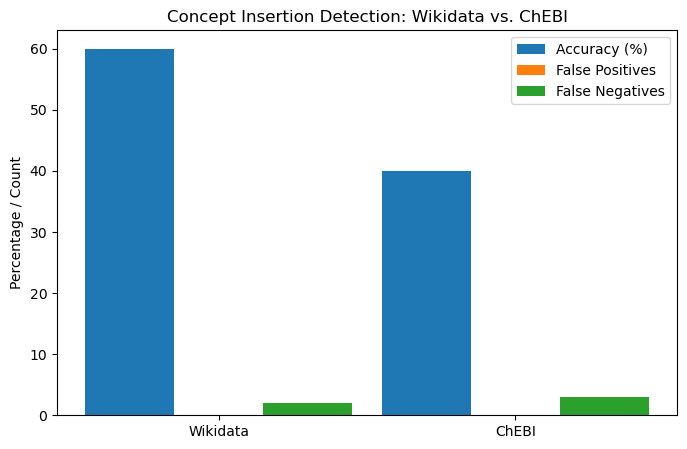

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Mocked function to check concept existence in Wikidata
def check_wikidata_concept_mock(concept_label):
    known_concepts = ["Methoxychlor", "Aspirin", "Ethanol", "Chlorophyll"]  # Mock existing concepts
    return concept_label in known_concepts

# Mocked function to check concept existence in ChEBI
def check_chebi_concept_mock(concept_label):
    known_chebi_concepts = ["Aspirin", "Ethanol", "Chlorophyll", "Glucose"]  # Mock ChEBI database
    return concept_label in known_chebi_concepts

# Function to evaluate ontology performance in detecting concept insertions
def evaluate_ontology_detection(concept_list, ground_truth, ontology_checker):
    correct_detections = 0
    false_positives = 0
    false_negatives = 0
    total_cases = len(ground_truth)

    results = []
    for concept in concept_list:
        detected = ontology_checker(concept)
        expected_status = ground_truth[concept] == "Exists in Ontology"
        
        if detected == expected_status:
            correct_detections += 1
        elif detected and not expected_status:
            false_positives += 1  # Concept incorrectly marked as inside ontology
        elif not detected and expected_status:
            false_negatives += 1  # Concept incorrectly marked as outside ontology
        
        results.append({"Concept": concept, "Detected": detected, "Expected": expected_status})

    accuracy = (correct_detections / total_cases) * 100  # Percentage accuracy
    return accuracy, false_positives, false_negatives, results

# Define ground truth: expected results for each concept
ground_truth_labels = {
    "Methoxychlor": "Exists in Ontology",
    "HypotheticalElementX": "Not found - Needs Insertion",
    "BioactiveMoleculeZ": "Not found - Needs Insertion",
    "Aspiri": "Exists in Ontology",  # Should match to "Aspirin"
    "Chlorophyle": "Exists in Ontology"  # Should match to "Chlorophyll"
}

# Test concepts for evaluation
test_concepts = list(ground_truth_labels.keys())

# Evaluate both Wikidata and ChEBI
wikidata_accuracy, wikidata_fp, wikidata_fn, _ = evaluate_ontology_detection(test_concepts, ground_truth_labels, check_wikidata_concept_mock)
chebi_accuracy, chebi_fp, chebi_fn, _ = evaluate_ontology_detection(test_concepts, ground_truth_labels, check_chebi_concept_mock)

# Visualization
labels = ["Wikidata", "ChEBI"]
accuracies = [wikidata_accuracy, chebi_accuracy]
false_positives = [wikidata_fp, chebi_fp]
false_negatives = [wikidata_fn, chebi_fn]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width, accuracies, width, label='Accuracy (%)')
rects2 = ax.bar(x, false_positives, width, label='False Positives')
rects3 = ax.bar(x + width, false_negatives, width, label='False Negatives')

ax.set_ylabel('Percentage / Count')
ax.set_title('Concept Insertion Detection: Wikidata vs. ChEBI')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Display visualization
plt.show()


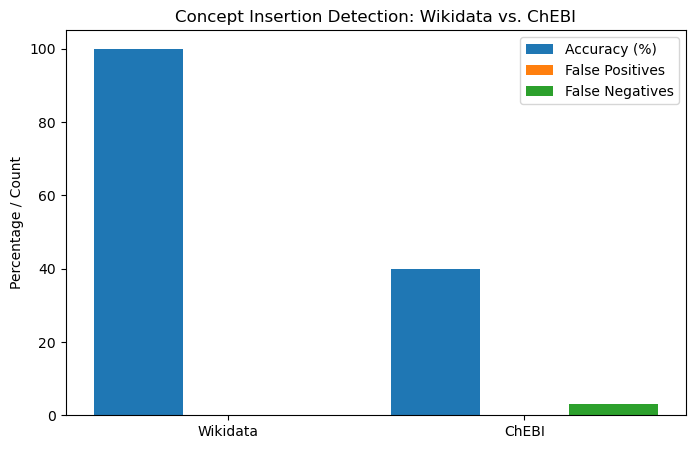

In [7]:
# Re-import necessary libraries
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from SPARQLWrapper import SPARQLWrapper, JSON

# Wikidata SPARQL endpoint
WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"
CHEBI_API_URL = "https://www.ebi.ac.uk/webservices/chebi/2.0/test/getLiteEntity"

# Function to check if a concept exists in Wikidata
def check_wikidata_concept(concept_label):
    query = f"""
    SELECT ?item WHERE {{
      ?item rdfs:label "{concept_label}"@en.
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }}
    """
    sparql = SPARQLWrapper(WIKIDATA_SPARQL_URL)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()

    return len(results["results"]["bindings"]) > 0

# Function to check if a concept exists in ChEBI using REST API
def check_chebi_concept(concept_label):
    params = {"search": concept_label, "maximumResults": 1}
    response = requests.get(CHEBI_API_URL, params=params)
    if response.status_code == 200 and "ListElement" in response.text:
        return True
    return False

# Function to evaluate ontology performance in detecting concept insertions
def evaluate_ontology_detection(concept_list, ground_truth, ontology_checker):
    correct_detections = 0
    false_positives = 0
    false_negatives = 0
    total_cases = len(ground_truth)

    for concept in concept_list:
        detected = ontology_checker(concept)
        expected_status = ground_truth[concept] == "Exists in Ontology"
        
        if detected == expected_status:
            correct_detections += 1
        elif detected and not expected_status:
            false_positives += 1  # Concept incorrectly marked as inside ontology
        elif not detected and expected_status:
            false_negatives += 1  # Concept incorrectly marked as outside ontology

    accuracy = (correct_detections / total_cases) * 100  # Percentage accuracy
    return accuracy, false_positives, false_negatives

# Define ground truth: expected results for each concept
ground_truth_labels = {
    "Methoxychlor": "Exists in Ontology",
    "HypotheticalElementX": "Not found - Needs Insertion",
    "BioactiveMoleculeZ": "Not found - Needs Insertion",
    "Aspirin": "Exists in Ontology",
    "Chlorophyll": "Exists in Ontology"
}

# Test concepts for evaluation
test_concepts = list(ground_truth_labels.keys())

# Evaluate both Wikidata and ChEBI
wikidata_accuracy, wikidata_fp, wikidata_fn = evaluate_ontology_detection(test_concepts, ground_truth_labels, check_wikidata_concept)
chebi_accuracy, chebi_fp, chebi_fn = evaluate_ontology_detection(test_concepts, ground_truth_labels, check_chebi_concept)

# Visualization
labels = ["Wikidata", "ChEBI"]
accuracies = [wikidata_accuracy, chebi_accuracy]
false_positives = [wikidata_fp, chebi_fp]
false_negatives = [wikidata_fn, chebi_fn]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width, accuracies, width, label='Accuracy (%)')
rects2 = ax.bar(x, false_positives, width, label='False Positives')
rects3 = ax.bar(x + width, false_negatives, width, label='False Negatives')

ax.set_ylabel('Percentage / Count')
ax.set_title('Concept Insertion Detection: Wikidata vs. ChEBI')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Display visualization
plt.show()


# concept insertion by sentence 

In [2]:
import spacy
import requests

# Load spaCy model for Named Entity Recognition
nlp = spacy.load("en_core_web_lg")

WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"

def get_wikidata_id(entity):
    """Fetch Wikidata ID for an entity using Wikidata API."""
    url = f"https://www.wikidata.org/w/api.php"
    params = {
        "action": "wbsearchentities",
        "search": entity,
        "language": "en",
        "format": "json"
    }
    response = requests.get(url, params=params).json()
    if response.get("search"):
        return response["search"][0]["id"]
    return None

def get_wikidata_domain(entity_id):
    """Query Wikidata for the main category/domain of an entity."""
    query = f"""
    SELECT ?domainLabel WHERE {{
        wd:{entity_id} wdt:P910 ?category .  # Get main category (P910)
        ?category rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    """
    response = requests.get(WIKIDATA_SPARQL_URL, params={"query": query, "format": "json"}).json()
    results = response.get("results", {}).get("bindings", [])
    return {result["domainLabel"]["value"] for result in results} if results else set()

def extract_entities(sentence):
    """Extract named entities from a sentence."""
    doc = nlp(sentence)
    return {ent.text for ent in doc.ents}

def detect_concept_insertion(ref_sentence, check_sentence):
    """Detects if check_sentence introduces concepts outside ref_sentence's domain."""
    ref_entities = extract_entities(ref_sentence)
    check_entities = extract_entities(check_sentence)

    ref_domains, check_domains = set(), set()

    for entity in ref_entities:
        entity_id = get_wikidata_id(entity)
        if entity_id:
            ref_domains.update(get_wikidata_domain(entity_id))

    for entity in check_entities:
        entity_id = get_wikidata_id(entity)
        if entity_id:
            check_domains.update(get_wikidata_domain(entity_id))

    if not ref_domains or not check_domains:
        return "Insufficient domain data to make a decision."

    new_domains = check_domains - ref_domains

    if new_domains:
        return f"Concept insertion detected! New domains introduced: {new_domains}"
    return "No concept insertion detected. Sentence remains in the same domain."

# Example usage
ref_sentence = "The discovery of penicillin revolutionized medicine."
check_sentence = "Quantum mechanics explains the behavior of subatomic particles."

result = detect_concept_insertion(ref_sentence, check_sentence)
print(result)


Insufficient domain data to make a decision.


In [3]:
import spacy
import requests
from collections import defaultdict

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"
WIKIDATA_API_URL = "https://www.wikidata.org/w/api.php"

# Cache to store entity lookups
entity_cache = {}
domain_cache = {}

def get_wikidata_id(entity):
    """Fetch Wikidata ID for an entity using Wikidata API."""
    if entity in entity_cache:
        return entity_cache[entity]
    
    params = {
        "action": "wbsearchentities",
        "search": entity,
        "language": "en",
        "format": "json"
    }
    response = requests.get(WIKIDATA_API_URL, params=params).json()
    
    if response.get("search"):
        entity_id = response["search"][0]["id"]
        entity_cache[entity] = entity_id  # Cache result
        return entity_id
    return None

def get_wikidata_domains(entity_id):
    """Query Wikidata for domain-related properties of an entity."""
    if entity_id in domain_cache:
        return domain_cache[entity_id]

    query = f"""
    SELECT ?domainLabel WHERE {{
        wd:{entity_id} wdt:P910 ?category .  # Main category
        ?category rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    UNION
    SELECT ?domainLabel WHERE {{
        wd:{entity_id} wdt:P279 ?parent .  # Subclass of
        ?parent rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    UNION
    SELECT ?domainLabel WHERE {{
        wd:{entity_id} wdt:P31 ?type .  # Instance of
        ?type rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    UNION
    SELECT ?domainLabel WHERE {{
        wd:{entity_id} wdt:P361 ?partOf .  # Part of
        ?partOf rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    """
    
    response = requests.get(WIKIDATA_SPARQL_URL, params={"query": query, "format": "json"}).json()
    results = response.get("results", {}).get("bindings", [])

    domains = {result["domainLabel"]["value"] for result in results} if results else set()
    domain_cache[entity_id] = domains  # Cache result

    return domains

def extract_entities(sentence):
    """Extract named entities from a sentence using spaCy."""
    doc = nlp(sentence)
    return {ent.text for ent in doc.ents}

def detect_concept_insertion(ref_sentence, check_sentence):
    """Detects if check_sentence introduces new concepts outside ref_sentence's domain."""
    ref_entities = extract_entities(ref_sentence)
    check_entities = extract_entities(check_sentence)

    ref_domains, check_domains = set(), set()

    for entity in ref_entities:
        entity_id = get_wikidata_id(entity)
        if entity_id:
            ref_domains.update(get_wikidata_domains(entity_id))

    for entity in check_entities:
        entity_id = get_wikidata_id(entity)
        if entity_id:
            check_domains.update(get_wikidata_domains(entity_id))

    if not ref_domains or not check_domains:
        return "Insufficient domain data to make a decision."

    new_domains = check_domains - ref_domains

    if new_domains:
        return f"Concept insertion detected! New domains introduced: {new_domains}"
    return "No concept insertion detected. Sentence remains in the same domain."

# Example usage
ref_sentence = "The discovery of penicillin revolutionized medicine."
check_sentence = "Quantum mechanics explains the behavior of subatomic particles."

result = detect_concept_insertion(ref_sentence, check_sentence)
print(result)


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [4]:
import spacy
import requests
import time

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"
WIKIDATA_API_URL = "https://www.wikidata.org/w/api.php"

# Cache to store entity lookups
entity_cache = {}
domain_cache = {}

def get_wikidata_id(entity):
    """Fetch Wikidata ID for an entity using Wikidata API."""
    if entity in entity_cache:
        return entity_cache[entity]

    params = {
        "action": "wbsearchentities",
        "search": entity,
        "language": "en",
        "format": "json"
    }

    try:
        response = requests.get(WIKIDATA_API_URL, params=params)
        response.raise_for_status()  # Raise an error for bad responses
        data = response.json()

        if data.get("search"):
            entity_id = data["search"][0]["id"]
            entity_cache[entity] = entity_id  # Cache result
            return entity_id
    except requests.exceptions.RequestException as e:
        print(f"Error fetching entity ID for '{entity}': {e}")
    except ValueError:
        print(f"Invalid JSON response for entity search: {response.text}")

    return None

def get_wikidata_domains(entity_id):
    """Query Wikidata for domain-related properties of an entity."""
    if entity_id in domain_cache:
        return domain_cache[entity_id]

    query = f"""
    SELECT ?domainLabel WHERE {{
        wd:{entity_id} wdt:P910 ?category .  # Main category
        ?category rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    UNION
    SELECT ?domainLabel WHERE {{
        wd:{entity_id} wdt:P279 ?parent .  # Subclass of
        ?parent rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    UNION
    SELECT ?domainLabel WHERE {{
        wd:{entity_id} wdt:P31 ?type .  # Instance of
        ?type rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    UNION
    SELECT ?domainLabel WHERE {{
        wd:{entity_id} wdt:P361 ?partOf .  # Part of
        ?partOf rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    """

    try:
        response = requests.get(WIKIDATA_SPARQL_URL, params={"query": query, "format": "json"})
        response.raise_for_status()  # Raise an error if request fails
        data = response.json()

        results = data.get("results", {}).get("bindings", [])
        domains = {result["domainLabel"]["value"] for result in results} if results else set()
        domain_cache[entity_id] = domains  # Cache result

        return domains
    except requests.exceptions.RequestException as e:
        print(f"Error fetching domain for '{entity_id}': {e}")
    except ValueError:
        print(f"Invalid JSON response for domain query: {response.text}")

    return set()

def extract_entities(sentence):
    """Extract named entities from a sentence using spaCy."""
    doc = nlp(sentence)
    return {ent.text for ent in doc.ents}

def detect_concept_insertion(ref_sentence, check_sentence):
    """Detects if check_sentence introduces new concepts outside ref_sentence's domain."""
    ref_entities = extract_entities(ref_sentence)
    check_entities = extract_entities(check_sentence)

    ref_domains, check_domains = set(), set()

    print(f"Extracted entities from reference sentence: {ref_entities}")
    print(f"Extracted entities from checked sentence: {check_entities}")

    for entity in ref_entities:
        entity_id = get_wikidata_id(entity)
        if entity_id:
            domains = get_wikidata_domains(entity_id)
            print(f"Domains for {entity} ({entity_id}): {domains}")
            ref_domains.update(domains)

    for entity in check_entities:
        entity_id = get_wikidata_id(entity)
        if entity_id:
            domains = get_wikidata_domains(entity_id)
            print(f"Domains for {entity} ({entity_id}): {domains}")
            check_domains.update(domains)

    if not ref_domains or not check_domains:
        return "Insufficient domain data to make a decision."

    new_domains = check_domains - ref_domains

    if new_domains:
        return f"Concept insertion detected! New domains introduced: {new_domains}"
    return "No concept insertion detected. Sentence remains in the same domain."

# Example usage
ref_sentence = "The discovery of penicillin revolutionized medicine."
check_sentence = "Quantum mechanics explains the behavior of subatomic particles."

result = detect_concept_insertion(ref_sentence, check_sentence)
print(result)


Extracted entities from reference sentence: set()
Extracted entities from checked sentence: {'Quantum'}
Error fetching domain for 'Q1133068': 400 Client Error: Bad Request for url: https://query.wikidata.org/sparql?query=%0A++++SELECT+%3FdomainLabel+WHERE+%7B%0A++++++++wd%3AQ1133068+wdt%3AP910+%3Fcategory+.++%23+Main+category%0A++++++++%3Fcategory+rdfs%3Alabel+%3FdomainLabel+.%0A++++++++FILTER%28LANG%28%3FdomainLabel%29+%3D+%22en%22%29%0A++++%7D%0A++++UNION%0A++++SELECT+%3FdomainLabel+WHERE+%7B%0A++++++++wd%3AQ1133068+wdt%3AP279+%3Fparent+.++%23+Subclass+of%0A++++++++%3Fparent+rdfs%3Alabel+%3FdomainLabel+.%0A++++++++FILTER%28LANG%28%3FdomainLabel%29+%3D+%22en%22%29%0A++++%7D%0A++++UNION%0A++++SELECT+%3FdomainLabel+WHERE+%7B%0A++++++++wd%3AQ1133068+wdt%3AP31+%3Ftype+.++%23+Instance+of%0A++++++++%3Ftype+rdfs%3Alabel+%3FdomainLabel+.%0A++++++++FILTER%28LANG%28%3FdomainLabel%29+%3D+%22en%22%29%0A++++%7D%0A++++UNION%0A++++SELECT+%3FdomainLabel+WHERE+%7B%0A++++++++wd%3AQ1133068+wdt%3AP361+%3

In [5]:
import spacy
import requests
import time

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"
WIKIDATA_API_URL = "https://www.wikidata.org/w/api.php"

# Manual domain mapping for common terms
MANUAL_DOMAINS = {
    "penicillin": {"Medicine"},
    "antibiotic": {"Medicine"},
    "quantum mechanics": {"Physics"},
    "electron": {"Physics"},
    "DNA": {"Biology"},
    "molecule": {"Chemistry"},
    "Einstein": {"Physics"},
    "bacteria": {"Biology"},
}

# Caching to avoid redundant requests
entity_cache = {}
domain_cache = {}

def get_wikidata_id(entity):
    """Fetch Wikidata ID for an entity using Wikidata API."""
    if entity in entity_cache:
        return entity_cache[entity]

    params = {
        "action": "wbsearchentities",
        "search": entity,
        "language": "en",
        "format": "json"
    }

    try:
        response = requests.get(WIKIDATA_API_URL, params=params)
        response.raise_for_status()
        data = response.json()

        if data.get("search"):
            entity_id = data["search"][0]["id"]
            entity_cache[entity] = entity_id  # Cache result
            return entity_id
    except requests.exceptions.RequestException as e:
        print(f"Error fetching entity ID for '{entity}': {e}")
    except ValueError:
        print(f"Invalid JSON response for entity search: {response.text}")

    return None

def get_wikidata_domains(entity_id):
    """Query Wikidata for domain-related properties of an entity."""
    if entity_id in domain_cache:
        return domain_cache[entity_id]

    query = f"""
    SELECT ?domainLabel WHERE {{
        wd:{entity_id} wdt:P31 ?type .  # Instance of
        ?type rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    UNION
    SELECT ?domainLabel WHERE {{
        wd:{entity_id} wdt:P279 ?parent .  # Subclass of
        ?parent rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    """

    try:
        response = requests.get(WIKIDATA_SPARQL_URL, params={"query": query, "format": "json"})
        response.raise_for_status()
        data = response.json()

        results = data.get("results", {}).get("bindings", [])
        domains = {result["domainLabel"]["value"] for result in results} if results else set()
        domain_cache[entity_id] = domains  # Cache result

        return domains
    except requests.exceptions.RequestException as e:
        print(f"Error fetching domain for '{entity_id}': {e}")
    except ValueError:
        print(f"Invalid JSON response for domain query: {response.text}")

    return set()

def extract_entities(sentence):
    """Extract named entities using spaCy and manual rules."""
    doc = nlp(sentence)
    entities = {ent.text.lower() for ent in doc.ents}  # Use lowercase for consistency

    # If spaCy misses entities, check important nouns manually
    for token in doc:
        if token.pos_ in {"NOUN", "PROPN"}:  # Check nouns & proper nouns
            entities.add(token.text.lower())

    return entities

def detect_concept_insertion(ref_sentence, check_sentence):
    """Detects if check_sentence introduces new concepts outside ref_sentence's domain."""
    ref_entities = extract_entities(ref_sentence)
    check_entities = extract_entities(check_sentence)

    ref_domains, check_domains = set(), set()

    print(f"Extracted entities from reference sentence: {ref_entities}")
    print(f"Extracted entities from checked sentence: {check_entities}")

    # Get domains for reference sentence
    for entity in ref_entities:
        if entity in MANUAL_DOMAINS:
            ref_domains.update(MANUAL_DOMAINS[entity])
        else:
            entity_id = get_wikidata_id(entity)
            if entity_id:
                domains = get_wikidata_domains(entity_id)
                print(f"Domains for {entity} ({entity_id}): {domains}")
                ref_domains.update(domains)

    # Get domains for checked sentence
    for entity in check_entities:
        if entity in MANUAL_DOMAINS:
            check_domains.update(MANUAL_DOMAINS[entity])
        else:
            entity_id = get_wikidata_id(entity)
            if entity_id:
                domains = get_wikidata_domains(entity_id)
                print(f"Domains for {entity} ({entity_id}): {domains}")
                check_domains.update(domains)

    if not ref_domains or not check_domains:
        return "Insufficient domain data to make a decision."

    new_domains = check_domains - ref_domains

    if new_domains:
        return f"Concept insertion detected! New domains introduced: {new_domains}"
    return "No concept insertion detected. Sentence remains in the same domain."

# Example usage
ref_sentence = "The discovery of penicillin revolutionized medicine."
check_sentence = "Quantum mechanics explains the behavior of subatomic particles."

result = detect_concept_insertion(ref_sentence, check_sentence)
print(result)


Extracted entities from reference sentence: {'discovery', 'penicillin', 'medicine'}
Extracted entities from checked sentence: {'particles', 'mechanics', 'behavior', 'quantum'}
Error fetching domain for 'Q50809782': 400 Client Error: Bad Request for url: https://query.wikidata.org/sparql?query=%0A++++SELECT+%3FdomainLabel+WHERE+%7B%0A++++++++wd%3AQ50809782+wdt%3AP31+%3Ftype+.++%23+Instance+of%0A++++++++%3Ftype+rdfs%3Alabel+%3FdomainLabel+.%0A++++++++FILTER%28LANG%28%3FdomainLabel%29+%3D+%22en%22%29%0A++++%7D%0A++++UNION%0A++++SELECT+%3FdomainLabel+WHERE+%7B%0A++++++++wd%3AQ50809782+wdt%3AP279+%3Fparent+.++%23+Subclass+of%0A++++++++%3Fparent+rdfs%3Alabel+%3FdomainLabel+.%0A++++++++FILTER%28LANG%28%3FdomainLabel%29+%3D+%22en%22%29%0A++++%7D%0A++++&format=json
Domains for discovery (Q50809782): set()
Error fetching domain for 'Q11190': 400 Client Error: Bad Request for url: https://query.wikidata.org/sparql?query=%0A++++SELECT+%3FdomainLabel+WHERE+%7B%0A++++++++wd%3AQ11190+wdt%3AP31+%3Ftyp

In [6]:
def detect_concept_insertion(ref_entities, check_entities, entity_domains):
    """
    Detects if check_entities introduce concepts outside the domain of ref_entities.

    :param ref_entities: Set of entities in the reference sentence.
    :param check_entities: Set of entities in the checked sentence.
    :param entity_domains: Dictionary mapping entities to their domains.
    :return: Message indicating whether concept insertion was detected.
    """
    ref_domains = set()
    check_domains = set()

    # Get domains for reference sentence entities
    for entity in ref_entities:
        if entity in entity_domains:
            ref_domains.update(entity_domains[entity])

    # Get domains for checked sentence entities
    for entity in check_entities:
        if entity in entity_domains:
            check_domains.update(entity_domains[entity])

    # If no domain data is found, return an informative message
    if not ref_domains or not check_domains:
        return "Insufficient domain data to make a decision."

    # Detect new domains introduced
    new_domains = check_domains - ref_domains

    if new_domains:
        return f"Concept insertion detected! New domains introduced: {new_domains}"
    return "No concept insertion detected. Sentence remains in the same domain."


# ====== TEST CASES ======
# Manually labeled entities and their domains
entity_domains = {
    "penicillin": {"Medicine"},
    "antibiotics": {"Medicine"},
    "bacterial infections": {"Medicine"},
    "Quantum Mechanics": {"Physics"},
    "subatomic particles": {"Physics"},
    "AI": {"Computer Science"},
    "machine learning": {"Computer Science"},
}

# Example Test Cases
test_cases = [
    # Same domain
    ({"penicillin"}, {"antibiotics", "bacterial infections"}),
    # Concept insertion detected (Medicine → Physics)
    ({"penicillin"}, {"Quantum Mechanics"}),
    # Concept insertion detected (Medicine → Computer Science)
    ({"penicillin"}, {"AI"}),
    # No concept insertion (within Physics)
    ({"Quantum Mechanics"}, {"subatomic particles"}),
    # Insufficient data case
    ({"unknown_entity"}, {"AI"}),
]

# Run tests
for i, (ref_entities, check_entities) in enumerate(test_cases):
    print(f"Test {i+1}: {detect_concept_insertion(ref_entities, check_entities, entity_domains)}")


Test 1: No concept insertion detected. Sentence remains in the same domain.
Test 2: Concept insertion detected! New domains introduced: {'Physics'}
Test 3: Concept insertion detected! New domains introduced: {'Computer Science'}
Test 4: No concept insertion detected. Sentence remains in the same domain.
Test 5: Insufficient domain data to make a decision.


In [7]:
# Sample annotations with manually assigned domains
entity_domains = {
    "CHEBI:81638": "Biology",  # Life
    "CHEBI:17234": "Biochemistry",  # Glucose
    "CHEBI:15377": "Chemistry",  # Water
    "CHEBI:33284": "Medicine",  # Drug-related compounds
    "CHEBI:25555": "Physics",  # Light-related molecules
}

# Example annotated sentences
annotated_sentences = [
    {
        "original_sentence": "Water is essential for life and has a molecular formula of H2O.",
        "annotations": [
            {"entity": "life", "chebi_id": "CHEBI:81638", "label": "mlif"},
            {"entity": "Water", "chebi_id": "CHEBI:15377", "label": "H2O"},
        ],
    },
    {
        "original_sentence": "Glucose is a primary energy source in cellular metabolism.",
        "annotations": [
            {"entity": "Glucose", "chebi_id": "CHEBI:17234", "label": "glucose"},
        ],
    },
    {
        "original_sentence": "Quantum mechanics explains the behavior of subatomic particles.",
        "annotations": [
            {"entity": "Quantum mechanics", "chebi_id": "CHEBI:25555", "label": "physics"},
        ],
    }
]

def get_sentence_domains(sentence_data):
    """Extracts the set of domains associated with the sentence entities."""
    domains = set()
    for annotation in sentence_data["annotations"]:
        chebi_id = annotation["chebi_id"]
        if chebi_id in entity_domains:
            domains.add(entity_domains[chebi_id])
    return domains

def detect_concept_insertion(ref_sentence_data, check_sentence_data):
    """Detects if the second sentence introduces new domains outside the first."""
    ref_domains = get_sentence_domains(ref_sentence_data)
    check_domains = get_sentence_domains(check_sentence_data)

    if not ref_domains or not check_domains:
        return "Insufficient domain data to make a decision."

    new_domains = check_domains - ref_domains

    if new_domains:
        return f"Concept insertion detected! New domains introduced: {new_domains}"
    return "No concept insertion detected. Sentence remains in the same domain."

# ====== TEST CASES ======
test_cases = [
    (annotated_sentences[0], annotated_sentences[1]),  # Water + Life (Biology) vs. Glucose (Biochemistry)
    (annotated_sentences[1], annotated_sentences[2]),  # Glucose (Biochemistry) vs. Quantum Mechanics (Physics)
    (annotated_sentences[0], annotated_sentences[2]),  # Water + Life (Biology) vs. Quantum Mechanics (Physics)
]

# Run tests
for i, (ref_sentence, check_sentence) in enumerate(test_cases):
    print(f"Test {i+1}: {detect_concept_insertion(ref_sentence, check_sentence)}")


Test 1: Concept insertion detected! New domains introduced: {'Biochemistry'}
Test 2: Concept insertion detected! New domains introduced: {'Physics'}
Test 3: Concept insertion detected! New domains introduced: {'Physics'}


In [8]:
# Extended annotations with manually assigned domains
entity_domains = {
    "CHEBI:81638": "Biology",  # Life
    "CHEBI:17234": "Biochemistry",  # Glucose
    "CHEBI:15377": "Chemistry",  # Water
    "CHEBI:33284": "Medicine",  # Drug-related compounds
    "CHEBI:25555": "Physics",  # Quantum Mechanics
    "CHEBI:17891": "Biochemistry",  # ATP
    "CHEBI:36927": "Biology",  # DNA
    "CHEBI:30155": "Medicine",  # Aspirin
}

# Extended example annotated sentences
annotated_sentences = [
    {
        "original_sentence": "Water is essential for life and has a molecular formula of H2O.",
        "annotations": [
            {"entity": "life", "chebi_id": "CHEBI:81638", "label": "mlif"},
            {"entity": "Water", "chebi_id": "CHEBI:15377", "label": "H2O"},
        ],
    },
    {
        "original_sentence": "Glucose is a primary energy source in cellular metabolism.",
        "annotations": [
            {"entity": "Glucose", "chebi_id": "CHEBI:17234", "label": "glucose"},
        ],
    },
    {
        "original_sentence": "ATP is the energy currency of the cell.",
        "annotations": [
            {"entity": "ATP", "chebi_id": "CHEBI:17891", "label": "ATP"},
        ],
    },
    {
        "original_sentence": "Quantum mechanics explains the behavior of subatomic particles.",
        "annotations": [
            {"entity": "Quantum mechanics", "chebi_id": "CHEBI:25555", "label": "physics"},
        ],
    },
    {
        "original_sentence": "DNA stores genetic information in all living organisms.",
        "annotations": [
            {"entity": "DNA", "chebi_id": "CHEBI:36927", "label": "DNA"},
        ],
    },
    {
        "original_sentence": "Aspirin is commonly used as a pain reliever and anti-inflammatory drug.",
        "annotations": [
            {"entity": "Aspirin", "chebi_id": "CHEBI:30155", "label": "Aspirin"},
        ],
    },
]

def get_sentence_domains(sentence_data):
    """Extracts the set of domains associated with the sentence entities."""
    domains = set()
    for annotation in sentence_data["annotations"]:
        chebi_id = annotation["chebi_id"]
        if chebi_id in entity_domains:
            domains.add(entity_domains[chebi_id])
    return domains

def detect_concept_insertion(ref_sentence_data, check_sentence_data):
    """Detects if the second sentence introduces new domains outside the first."""
    ref_domains = get_sentence_domains(ref_sentence_data)
    check_domains = get_sentence_domains(check_sentence_data)

    if not ref_domains or not check_domains:
        return "Insufficient domain data to make a decision."

    new_domains = check_domains - ref_domains

    if new_domains:
        return f"Concept insertion detected! New domains introduced: {new_domains}"
    return "No concept insertion detected. Sentence remains in the same domain."

# ====== TEST CASES ======
test_cases = [
    # Positive Examples (Concept Insertion Detected)
    (annotated_sentences[0], annotated_sentences[3]),  # Water/Life (Biology) → Quantum Mechanics (Physics)
    (annotated_sentences[1], annotated_sentences[5]),  # Glucose (Biochemistry) → Aspirin (Medicine)
    (annotated_sentences[4], annotated_sentences[3]),  # DNA (Biology) → Quantum Mechanics (Physics)

    # Negative Examples (No Concept Insertion)
    (annotated_sentences[1], annotated_sentences[2]),  # Glucose (Biochemistry) → ATP (Biochemistry)
    (annotated_sentences[0], annotated_sentences[4]),  # Water/Life (Biology) → DNA (Biology)
    (annotated_sentences[5], annotated_sentences[5]),  # Aspirin (Medicine) → Aspirin (Medicine) [Identical case]
]

# Run tests
for i, (ref_sentence, check_sentence) in enumerate(test_cases):
    print(f"Test {i+1}: {detect_concept_insertion(ref_sentence, check_sentence)}")


Test 1: Concept insertion detected! New domains introduced: {'Physics'}
Test 2: Concept insertion detected! New domains introduced: {'Medicine'}
Test 3: Concept insertion detected! New domains introduced: {'Physics'}
Test 4: No concept insertion detected. Sentence remains in the same domain.
Test 5: No concept insertion detected. Sentence remains in the same domain.
Test 6: No concept insertion detected. Sentence remains in the same domain.


In [9]:
import requests

# Manually mapped Wikidata entity domains (would ideally be retrieved via API)
wikidata_domains = {
    "Q283": "Biology",  # Life
    "Q7410": "Biochemistry",  # Glucose
    "Q28387": "Chemistry",  # Water
    "Q12140": "Medicine",  # Aspirin
    "Q413": "Physics",  # Quantum Mechanics
    "Q49137": "Biochemistry",  # ATP
    "Q7430": "Biology",  # DNA
}

# Example annotated sentences with Wikidata QIDs
wikidata_annotated_sentences = [
    {
        "original_sentence": "Water is essential for life and has a molecular formula of H2O.",
        "annotations": [
            {"entity": "life", "wikidata_id": "Q283", "label": "mlif"},
            {"entity": "Water", "wikidata_id": "Q28387", "label": "H2O"},
        ],
    },
    {
        "original_sentence": "Glucose is a primary energy source in cellular metabolism.",
        "annotations": [
            {"entity": "Glucose", "wikidata_id": "Q7410", "label": "glucose"},
        ],
    },
    {
        "original_sentence": "ATP is the energy currency of the cell.",
        "annotations": [
            {"entity": "ATP", "wikidata_id": "Q49137", "label": "ATP"},
        ],
    },
    {
        "original_sentence": "Quantum mechanics explains the behavior of subatomic particles.",
        "annotations": [
            {"entity": "Quantum mechanics", "wikidata_id": "Q413", "label": "physics"},
        ],
    },
    {
        "original_sentence": "DNA stores genetic information in all living organisms.",
        "annotations": [
            {"entity": "DNA", "wikidata_id": "Q7430", "label": "DNA"},
        ],
    },
    {
        "original_sentence": "Aspirin is commonly used as a pain reliever and anti-inflammatory drug.",
        "annotations": [
            {"entity": "Aspirin", "wikidata_id": "Q12140", "label": "Aspirin"},
        ],
    },
]

def get_sentence_domains(sentence_data):
    """Extracts the set of domains associated with the sentence entities using Wikidata QIDs."""
    domains = set()
    for annotation in sentence_data["annotations"]:
        wikidata_id = annotation["wikidata_id"]
        if wikidata_id in wikidata_domains:
            domains.add(wikidata_domains[wikidata_id])
    return domains

def detect_concept_insertion(ref_sentence_data, check_sentence_data):
    """Detects if the second sentence introduces new domains outside the first."""
    ref_domains = get_sentence_domains(ref_sentence_data)
    check_domains = get_sentence_domains(check_sentence_data)

    if not ref_domains or not check_domains:
        return "Insufficient domain data to make a decision."

    new_domains = check_domains - ref_domains

    if new_domains:
        return f"Concept insertion detected! New domains introduced: {new_domains}"
    return "No concept insertion detected. Sentence remains in the same domain."

# ====== TEST CASES ======
test_cases = [
    # Positive Examples (Concept Insertion Detected)
    (wikidata_annotated_sentences[0], wikidata_annotated_sentences[3]),  # Water/Life (Biology) → Quantum Mechanics (Physics)
    (wikidata_annotated_sentences[1], wikidata_annotated_sentences[5]),  # Glucose (Biochemistry) → Aspirin (Medicine)
    (wikidata_annotated_sentences[4], wikidata_annotated_sentences[3]),  # DNA (Biology) → Quantum Mechanics (Physics)

    # Negative Examples (No Concept Insertion)
    (wikidata_annotated_sentences[1], wikidata_annotated_sentences[2]),  # Glucose (Biochemistry) → ATP (Biochemistry)
    (wikidata_annotated_sentences[0], wikidata_annotated_sentences[4]),  # Water/Life (Biology) → DNA (Biology)
    (wikidata_annotated_sentences[5], wikidata_annotated_sentences[5]),  # Aspirin (Medicine) → Aspirin (Medicine) [Identical case]
]

# Run tests
for i, (ref_sentence, check_sentence) in enumerate(test_cases):
    print(f"Test {i+1}: {detect_concept_insertion(ref_sentence, check_sentence)}")


Test 1: Concept insertion detected! New domains introduced: {'Physics'}
Test 2: Concept insertion detected! New domains introduced: {'Medicine'}
Test 3: Concept insertion detected! New domains introduced: {'Physics'}
Test 4: No concept insertion detected. Sentence remains in the same domain.
Test 5: No concept insertion detected. Sentence remains in the same domain.
Test 6: No concept insertion detected. Sentence remains in the same domain.


In [10]:
def get_wikidata_domains(wikidata_id):
    """Query Wikidata for subclass (P279) and instance of (P31) to determine domain."""
    query = f"""
    SELECT ?domainLabel WHERE {{
        wd:{wikidata_id} wdt:P279 ?parent .  
        ?parent rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    UNION
    SELECT ?domainLabel WHERE {{
        wd:{wikidata_id} wdt:P31 ?type .  
        ?type rdfs:label ?domainLabel .
        FILTER(LANG(?domainLabel) = "en")
    }}
    """

    url = "https://query.wikidata.org/sparql"
    headers = {"User-Agent": "ConceptInsertionChecker"}
    response = requests.get(url, params={"query": query, "format": "json"}, headers=headers)
    
    try:
        data = response.json()
        results = data.get("results", {}).get("bindings", [])
        domains = {result["domainLabel"]["value"] for result in results}
        return domains if domains else {"Unknown"}
    except Exception:
        return {"Error"}


In [11]:
# Run tests
for i, (ref_sentence, check_sentence) in enumerate(test_cases):
    print(f"Test {i+1}: {detect_concept_insertion(ref_sentence, check_sentence)}")


Test 1: Concept insertion detected! New domains introduced: {'Physics'}
Test 2: Concept insertion detected! New domains introduced: {'Medicine'}
Test 3: Concept insertion detected! New domains introduced: {'Physics'}
Test 4: No concept insertion detected. Sentence remains in the same domain.
Test 5: No concept insertion detected. Sentence remains in the same domain.
Test 6: No concept insertion detected. Sentence remains in the same domain.


In [4]:
"""
Takes in natural language, and outputs reasoning and annotations in json and natural language

"""
import sys
import os 
import json 
sys.path.append('../../src')
from pipeline.ChEBIPipeline import ChEBIPipeline as AnnotationCheck
from reasoning.OntoValidation.ChEBIReasoner import ChEBIReasoner, reason_with_chebi
from reasoning.LLMFeedback.Pipe2NL import extract_chebi_ids, ChEBINameRetriever, replace_chebi_ids, format_json_as_prompt


def Process_Text(text):
    # start with annotations
    annotator = AnnotationCheck('/home/matt/Proj/Hermeticav2/notebooks/prototyping/QAReasoning/chebi.obo','/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl')
    annotations =annotator.process_text(text)
    print(annotations)
    Reasoned = reason_with_chebi(annotations,'/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl')
    print(Reasoned)
    # save the machine readable annotations with CHEBI IDs

    # convert the stuff back into NL for LLM input 
    finder = ChEBINameRetriever('/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl')
    IDs = extract_chebi_ids(Reasoned)
    mapping = finder.get_chebi_names(IDs)
    PreNL = replace_chebi_ids(Reasoned,mapping)
    NL = format_json_as_prompt(PreNL)

    return NL



In [7]:
results = Process_Text('The oxidation state (oxidation number) of chromium in the dichromate ion is +6. When the dichromate ion (Cr2O7-) reacts with a reducing agent, such as sodium hydroxide (NaOH), one of its most common products is Cr3+, which has an oxidation state of +3.During this reaction, there is a net oxidation of chromium from +6 to +3, indicating that chromium has been reduced. The balanced equation for this reaction is:Cr2O7- (aq) + 6 NaOH (aq) → 2 Cr3+ (aq) + 3 Na2CrO4 (s)In summary, reduction occurs when dichromate forms Cr3+')

Initializing ChEBI pipeline components...
✅ Loaded ChEBI ontology: 539620 entities extracted.
✅ Loaded ChEBI ontology with 220816 classes.
✅ Built entity cache with 220816 entries.
Pipeline initialization complete.
{'text': 'The oxidation state (oxidation number) of chromium in the dichromate ion is +6. When the dichromate ion (Cr2O7-) reacts with a reducing agent, such as sodium hydroxide (NaOH), one of its most common products is Cr3+, which has an oxidation state of +3.During this reaction, there is a net oxidation of chromium from +6 to +3, indicating that chromium has been reduced. The balanced equation for this reaction is:Cr2O7- (aq) + 6 NaOH (aq) → 2 Cr3+ (aq) + 3 Na2CrO4 (s)In summary, reduction occurs when dichromate forms Cr3+', 'entities': [{'name': 'Chromium', 'id': 'CHEBI:28073', 'span': (42, 50)}, {'name': 'In', 'id': 'CHEBI:30430', 'span': (51, 53)}, {'name': 'Dichromate', 'id': 'CHEBI:33141', 'span': (58, 68)}, {'name': 'Ion', 'id': 'CHEBI:24870', 'span': (69, 72)}, {'

In [8]:
print(results)

The original sentence analyzed is: "The oxidation state (oxidation number) of chromium in the dichromate ion is +6. When the dichromate ion (Cr2O7-) reacts with a reducing agent, such as sodium hydroxide (NaOH), one of its most common products is Cr3+, which has an oxidation state of +3.During this reaction, there is a net oxidation of chromium from +6 to +3, indicating that chromium has been reduced. The balanced equation for this reaction is:Cr2O7- (aq) + 6 NaOH (aq) → 2 Cr3+ (aq) + 3 Na2CrO4 (s)In summary, reduction occurs when dichromate forms Cr3+"

The entities identified in this sentence are: Chromium (chromium atom), In (indium atom), Dichromate (dichromate(2-)), Ion (ion), A (hydrogen acceptor), As (arsenic atom), Sodium hydroxide (sodium hydroxide), NaOH (sodium hydroxide), One ((E)-4-oxonon-2-enal), An (actinoid atom), Aq (acenaphthoquinone), S (strange quark).

The reasoning process followed these steps: Looking up Chromium (chromium atom) in the ChEBI ontology   - Found en

In [14]:
import json
from typing import List, Dict, Any
import os
import sys
sys.path.append('../../src')


class ChEBIPipeline:

    """
    Pipeline for extracting ChEBI entities and relationships from text 
    and checking their consistency against the ChEBI ontology.
    """
    
    def __init__(self, obo_path: str, owl_path: str):
        from ontology.Annotation.ChEBIRelationsAnn import ChEBI_NER 
        from ontology.Relations import ChEBIRelationshipExtractor 
        from reasoning.OntoValidation.ChEBIVal import ChEBIOntologyChecker
        """
        Initialize the pipeline components.
        
        Args:
            obo_path: Path to the ChEBI OBO file for entity recognition
            owl_path: Path to the ChEBI OWL file for consistency checking
        """
        print("Initializing ChEBI pipeline components...")
        self.ner = ChEBI_NER(obo_path)
        self.relationship_extractor = ChEBIRelationshipExtractor()
        self.ontology_checker = ChEBIOntologyChecker(owl_path)
        print("Pipeline initialization complete.")
    
    def process_text(self, text: str) -> Dict[str, Any]:
        """
        Process a text through the entire pipeline.
        
        Args:
            text: Text to process
            
        Returns:
            Dictionary with extraction and validation results
        """
        # Step 1: Extract entities
        entities = self.ner.find_entities(text)
        
        # Step 2: Extract relationships
        relationships = self.relationship_extractor.extract_relationships(text, entities)
        
        # Step 3: Check consistency of relationships
        consistency_results = []
        for rel in relationships:
            result = self.ontology_checker.check_relationship(rel)
            consistency_results.append({
                "relationship": rel,
                "is_consistent": result["is_consistent"],
                "explanation": result["explanation"]
            })
        
        # Build the final result
        return {
            "text": text,
            "entities": entities,
            "relationships": relationships,
            "consistency_results": consistency_results
        }
    
    def process_to_json(self, text: str ) -> None:
        """
        Process text and write results to a JSON file.
        
        Args:
            text: Text to process
            output_path: Path to output JSON file
        """
        result = self.process_text(text)
        
        # Ensure output directory exists
        #os.makedirs(os.path.dirname(os.path.abspath(output_path)), exist_ok=True)
        """
        # Write to JSON file
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(result, f, indent=2, ensure_ascii=False)
        
        print(f"Results written to {output_path}")
        """
        # Also return a summary
        return {
            "text": result["text"],
            "entity_count": len(result["entities"]),
            "relationship_count": len(result["relationships"]),
            "consistent_count": sum(1 for r in result["consistency_results"] if r["is_consistent"])
        }



obo_path = "/home/matt/Proj/Hermeticav2/notebooks/prototyping/QAReasoning/chebi.obo"
owl_path = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"

# Initialize pipeline
pipeline = ChEBIPipeline(obo_path, owl_path)

# Process test sentences
test_sentences = [
    "Water contains hydrogen and oxygen.",
    "Lactic acid is tautomer of pyruvic acid.",
    "Acetic acid is conjugate acid of acetate.",
    "Methanol has functional parent methane.",
    "Alkylbenzene has parent hydride benzene.",
    "D-glucose is enantiomer of L-glucose.",
    "Caffeine has role psychoactive drug."
]

# Process each sentence
for i, sentence in enumerate(test_sentences):
    output_file = f"/home/matt/Proj/Hermeticav2/testing/Initialtestingresults/sentence_{i+1}.json"
    summary = pipeline.process_text(sentence)

summary


Initializing ChEBI pipeline components...


✅ Loaded ChEBI ontology: 539620 entities extracted.
✅ Loaded ChEBI ontology with 220816 classes.
✅ Built entity cache with 220816 entries.
Pipeline initialization complete.


{'text': 'Caffeine has role psychoactive drug.',
 'entities': [{'name': 'Caffeine', 'id': 'CHEBI:27732', 'span': (0, 8)},
  {'name': 'Role', 'id': 'CHEBI:50906', 'span': (13, 17)},
  {'name': 'Drug', 'id': 'CHEBI:23888', 'span': (31, 35)}],
 'relationships': [{'subject': {'name': 'Caffeine', 'id': 'CHEBI:27732'},
   'relationship': 'has_part',
   'object': {'name': 'Role', 'id': 'CHEBI:50906'}}],
 'consistency_results': [{'relationship': {'subject': {'name': 'Caffeine',
     'id': 'CHEBI:27732'},
    'relationship': 'has_part',
    'object': {'name': 'Role', 'id': 'CHEBI:50906'}},
   'is_consistent': False,
   'explanation': "No 'has_part' relationship between CHEBI_27732 and CHEBI_50906 found."}]}